# Breaking Hardware AES on CW305 FPGA

This tutorial relies on previous knowledge from the SCA101 course notebooks (in `../courses/sca101/`); make sure you go through these first to understand how a CPA attack works.

In this notebook, we'll apply knowledge from sca101 to break a hardware AES implementation on the CW305 Artix FPGA.

Some out-of-date background on the target FPGA project is can be found here: [Tutorial CW305-1 Building a Project](http://wiki.newae.com/Tutorial_CW305-1_Building_a_Project) (ignore the "capture setup" section, which uses the obsolete ChipWhisperer GUI; this notebook shows all you need to know about capture setup on the CW305 with Jupyter).

## Background Theory
During this tutorial, we'll be working with a hardware AES implementation. This type of attack can be much more difficult than a software AES attack. In the software AES attacks, we needed hundreds or thousands of clock cycles to capture the algorithm's full execution. In contrast, a hardware AES implementation may have a variety of speeds. Depending on the performance of the hardware, a whole spectrum of execution speeds can be achieved by executing many operations in a single clock cycle. It is theoretically possible to execute the entire AES encryption in a single cycle, given enough hardware space and provided that the clock is not too fast. Most hardware accelerators are designed to complete one round or one large part of a round in a single cycle.

This fast execution may cause problems with a regular CPA attack. In software, we found that it was easy to search for the outputs of the s-boxes because these values would need to be loaded from memory onto a high-capacitance data bus. This is not necessarily true on an FPGA, where the output of the s-boxes may be directly fed into the next stage of the algorithm. In general, we may need some more knowledge of the hardware implementation to successfully complete an attack.

In our case, let's suppose that every round of AES is completed in a single clock cycle. Recall the execution of AES:

<img src="img/aes_operations.png" width="250">

Here, every blue block is executed in one clock cycle. This means that an excellent candidate for a CPA attack is the difference between the input and output of the final round. It is likely that this state is stored in a port that is updated every round, so we expect that the Hamming distance between the round input and output is the most important factor on the power consumption. Also, the last round is the easiest to attack because it has no MixColumns operation. We'll use this Hamming distance as the target in our CPA attack.

## Capture Notes

Most of the capture settings used below are similar to the standard ChipWhisperer scope settings. However, there are a couple of interesting points:

- We're only capturing 129 samples (the minimum allowed), and the encryption is completed in less than 60 samples with an x4 ADC clock. This makes sense - as we mentioned above, our AES implementation is computing each round in a single clock cycle.
- We're using EXTCLK x4 for our ADC clock. This means that the FPGA is outputting a clock signal, and we aren't driving it.

Other than these, the last interesting setting is the number of traces. By default, the capture software is ready to capture 5000 traces - many more than were required for software AES! It is difficult for us to measure the small power spikes from the Hamming distance on the last round: these signals are dwarfed by noise and the other operations on the chip. To deal with this small signal level, we need to capture many more traces.

## Capture Setup

Setup is somewhat similar to other targets, except that we are using an external clock (driven from the FPGA). We'll also do the rest of the setup manually:

In [1]:
FPGA_ID='100t' # change if not using K100t CW305

In [2]:
Trojan_ID = 'T1300'

In [3]:
import chipwhisperer as cw
scope = cw.scope()
scope.gain.db = 25
scope.adc.samples = 600
scope.adc.offset = 0
scope.adc.basic_mode = "rising_edge"
scope.trigger.triggers = "tio4"
scope.io.tio1 = "serial_rx"
scope.io.tio2 = "serial_tx"
scope.io.hs2 = "disabled"

In [4]:
bsfile = r"./T1300.bit"

Before setting the ADC clock, we connect to the CW305 board. Here we'll need to specify our bitstream file to load as well as the usual scope and target_type arguments.

Pick the correct bitfile for your CW305 board (e.g. either '35t' or '100t'). By setting `force=False`, the bitfile will only be programmed if the FPGA is uninitialized (e.g. after powering up). Change to `force=True` to always program the FPGA (e.g. if you have generated a new bitfile).

In [5]:
#target = cw.target(scope, cw.targets.CW305, fpga_id='35t', force=False)
target = cw.target(scope, cw.targets.CW305, fpga_id=FPGA_ID, force=True, bsfile=bsfile)

(ChipWhisperer Target WARNING|File CW305.py:591) Using default Verilog defines (C:\Users\j2217\ChipWhisperer\chipwhisperer\software\chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


Next we set all the PLLs. We enable CW305's PLL1; this clock will feed both the target and the CW ADC. As explained [here](http://wiki.newae.com/Tutorial_CW305-1_Building_a_Project#Capture_Setup), **make sure the DIP switches on the CW305 board are set as follows**:
- J16 = 0
- K16 = 1

In [6]:
target.vccint_set(1.0)
# we only need PLL1:
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(False, 0)
target.pll.pll_outenable_set(True, 1)
target.pll.pll_outenable_set(False, 2)

# run at 10 MHz:
target.pll.pll_outfreq_set(10E6, 1)

# 1ms is plenty of idling time
target.clkusbautooff = True
target.clksleeptime = 1

CW-Husky requires a different setup when the ADC clock is driven by the target:

In [7]:
if scope._is_husky:
    scope.clock.clkgen_freq = 10e6
    scope.clock.clkgen_src = 'extclk'
    scope.clock.adc_mul = 8
    # if the target PLL frequency is changed, the above must also be changed accordingly
else:
    scope.clock.adc_src = "extclk_x4"

Ensure the ADC clock is locked:

In [8]:
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

Occasionally the ADC will fail to lock on the first try; when that happens, the above assertion will fail (and on the CW-Lite, the red LED will be on). Simply re-running the above cell again should fix things.

## Trace Capture
Below is the capture loop. The main body of the loop loads some new plaintext, arms the scope, sends the key and plaintext, then finally records and appends our new trace to the `traces[]` list.

Because we're capturing 5000 traces, this takes a bit longer than the attacks against software AES implementations.

Note that the encryption result is read from the target and compared to the expected results, as a sanity check.

In [9]:
project_file = "./"
project = cw.create_project(project_file, overwrite=True)

In [11]:
from tqdm.notebook import trange
import numpy as np
import time
from Crypto.Cipher import AES
import random
import time
ktp = cw.ktp.Basic()



traces = []
textin = []
keys = []
N = 10000  # Number of traces

# initialize cipher to verify DUT result:
key, text = ktp.next()
cipher = AES.new(bytes(key), AES.MODE_ECB)
testkey = [[]]
for i in trange(N, desc='Capturing traces'):
    # run aux stuff that should come before trace here
    testkey = []
    key, text = ktp.next()  # manual creation of a key, text pair can be substituted here
    
    text = [0xFF]*16
    for r in range(16):
        key[r] = random.randint(0, 255)
    print(key)
    cipher = AES.new(bytes(key), AES.MODE_ECB)


    textin.append(text)
    keys.append(key)
    
    ret = cw.capture_trace(scope, target, text, key)
    if not ret:
        print("Failed capture")
        continue
    time.sleep(0.2)
    assert (list(ret.textout) == list(cipher.encrypt(bytes(text)))), "Incorrect encryption result!\nGot {}\nExp {}\n".format(ret.textout, list(text))
    
    traces.append(ret.wave)
    project.traces.append(ret)

Capturing traces:   0%|          | 0/10000 [00:00<?, ?it/s]

CWbytearray(b'f0 16 52 d4 be 50 84 83 48 68 77 df 44 39 3a 3c')
CWbytearray(b'0b 97 06 c7 ab aa ca e4 b7 33 ca ce 9e 28 4f ec')
CWbytearray(b'77 4b 41 a1 8d 87 fa 21 7c e1 31 fc 10 65 4a 0b')
CWbytearray(b'64 a0 e2 52 d6 d8 84 b9 03 6e d6 75 63 ab 13 c9')
CWbytearray(b'14 6e 4f d6 dc f2 b7 aa cc 5c 67 b0 db a3 49 1a')
CWbytearray(b'a6 ef fc 83 4a d3 f6 f3 c8 0a a3 6c 81 eb ee 99')
CWbytearray(b'f3 f5 c3 74 2a 3e 50 c7 2c a2 86 36 97 c1 42 54')
CWbytearray(b'db 35 8f 2b 83 9e 85 a6 83 a8 ad b0 53 8b 9e ee')
CWbytearray(b'ce 36 a4 68 52 07 59 3f 8d 0b 78 46 e8 db 24 9f')
CWbytearray(b'9d f3 4e 93 f7 4f 4f 2f a9 7a 3a 44 bb 5e fd ea')
CWbytearray(b'6f 7f af 9b 28 76 57 10 cc c0 14 da c3 64 83 3d')
CWbytearray(b'07 1b b4 43 2b 9f b1 6e 90 33 88 22 d4 9b f3 b0')
CWbytearray(b'e7 27 7b 6c 70 9a d6 57 bf bd f1 2f ec 0b 23 ef')
CWbytearray(b'6a d6 d5 79 81 97 47 c6 b7 28 ab bb 67 ae 21 5f')
CWbytearray(b'0f d5 31 31 9a 88 a3 62 5f d4 25 7d 76 6c 5b 5c')
CWbytearray(b'3e bf 01 5f a8 7d ee fd 9c

In [11]:
np.save('./AES_%s.npy'%Trojan_ID , traces)

In [10]:
from datetime import datetime
import os

now = datetime.now().strftime('%Y.%m.%d-%H.%M.%S')
os.mkdir(now)

traces_array  = np.asarray([traces.wave for trace in traces])
textin_array  = np.asarray([traces.textin for trace in traces])
textout_array = np.asarray([traces.textout for trace in traces])
keylist_array = np.asarray([traces.key for trace in traces])

np.save('%s/%s_traces'%(now, now), traces_array)
np.save('%s/%s_textin'%(now, now), textin_array)
np.save('%s/%s_textout'%(now, now), textout_array)
np.save('%s/%s_keylist'%(now, now), keylist_array)

AttributeError: 'list' object has no attribute 'wave'

This shows how a captured trace can be plotted:

In [11]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

output_notebook()
p = figure(plot_width=800)

xrange = range(len(traces[0]))
p.line(xrange, traces[0], line_color="red")
show(p)

TypeError: publish_display_data() takes from 1 to 2 positional arguments but 3 positional arguments (and 1 keyword-only argument) were given

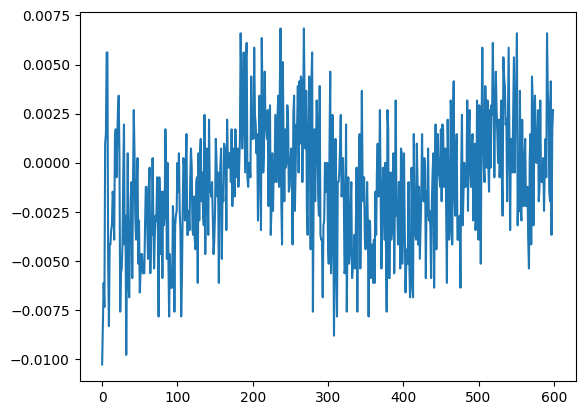

In [13]:
import matplotlib.pyplot as plt
plt.plot(traces[0]-traces[1])
plt.show()

In [14]:
np.save('./tr.npy' , traces)

In [9]:
from tqdm.notebook import trange
import numpy as np
import time
from Crypto.Cipher import AES

ktp = cw.ktp.Basic()

traces_t = []
textin = []
keys = []
N = 20000  # Number of traces

# 평문
plaintext = [
    0x32, 0x43, 0xf6, 0xa8,
    0x88, 0x5a, 0x30, 0x8d,
    0x31, 0x31, 0x98, 0xa2,
    0xe0, 0x37, 0x07, 0x34
]

key, text = ktp.next()
cipher = AES.new(bytes(key), AES.MODE_ECB)

for i in trange(N, desc='Capturing traces'):
    text, key = ktp.next()
    text = plaintext
    
    textin.append(text)
    keys.append(key)
    
    ret = cw.capture_trace(scope, target, text, key)
    if not ret:
        print("Failed capture")
        continue
    
    traces_t.append(ret.wave)
    project.traces.append(ret)

Capturing traces:   0%|          | 0/20000 [00:00<?, ?it/s]

In [10]:
from datetime import datetime
import os
now = datetime.now().strftime('%Y.%m.%d-%H.%M.%S')
os.mkdir(now)

traces_array  = np.asarray([ret.wave for trace in traces_t])
textin_array  = np.asarray([ret.textin for trace in traces_t])
textout_array = np.asarray([ret.textout for trace in traces_t])
keylist_array = np.asarray([ret.key for trace in traces_t])

np.save('%s/%s_traces'%(now, now), traces_array)
np.save('%s/%s_textin'%(now, now), textin_array)
np.save('%s/%s_textout'%(now, now), textout_array)
np.save('%s/%s_keylist'%(now, now), keylist_array)

In [14]:
!pip install bokeh


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
output_notebook()
p = figure(plot_width=800)

xrange = range(len(traces_t[0]))
p.line(xrange, traces_t[0], line_color="red")
show(p)

TypeError: Object of type URL is not JSON serializable

Finally we save our traces and disconnect. By saving the traces, the attack can be repeated in the future without having to repeat the trace acquisition steps above.

In [17]:
#project.save()
scope.dis()
target.dis()

In [16]:
!pip install --upgrade bokeh==2.4.3

   ---------------------------------------- 0.0/18.5 MB ? eta -:--:--
   --------- ------------------------------ 4.2/18.5 MB 28.1 MB/s eta 0:00:01
   ---------------------- ----------------- 10.5/18.5 MB 28.5 MB/s eta 0:00:01
   ---------------------------------------  18.4/18.5 MB 29.7 MB/s eta 0:00:01
   ---------------------------------------- 18.5/18.5 MB 28.5 MB/s eta 0:00:00
  Attempting uninstall: bokeh
    Found existing installation: bokeh 3.6.3
    Uninstalling bokeh-3.6.3:
      Successfully uninstalled bokeh-3.6.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
holoviews 1.20.2 requires bokeh>=3.1, but you have bokeh 2.4.3 which is incompatible.
panel 1.6.1 requires bokeh<3.7.0,>=3.5.0, but you have bokeh 2.4.3 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
